# Uses shape outline for 3D reconstruction

In [118]:
# Imports
import os
import glob
import pickle
import numpy as np
import cv2 as cv
import pyvista as pv
import pymeshfix            # pip install pymeshfix
#import pymeshlab


#%pip install pyvista
#%pip install trame
#%pip install trame-vuetify
#%pip install trame-vtk

#%pip install pymeshlab

# for creating a responsive plot
#%matplotlib widget
 
# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pylab as plt



#-------------------------------------------------------------------------------
#                               load_image
#-------------------------------------------------------------------------------
def load_image(imageNum=0):

    filePath = f'bunny_pics/Bunny_{imageNum : 04d}deg.jpg'
    filePath = os.path.normpath(filePath)
    filePath = os.path.abspath(filePath)

    img = None

    if os.path.exists(filePath):

        print(f'Loading "{filePath}...')
        img = cv.imread(filePath)

    else:

        print(f'ERROR: Image file not found ({filePath})')

    return img


#-------------------------------------------------------------------------------
#                               show_image
#-------------------------------------------------------------------------------
def show_image(title='', opencvImage=None):

    if opencvImage is not None:
        plt.figure()
        plt.imshow(cv.cvtColor(opencvImage, cv.COLOR_BGR2RGB))
        plt.title(title)

    return

Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 000deg.jpg...


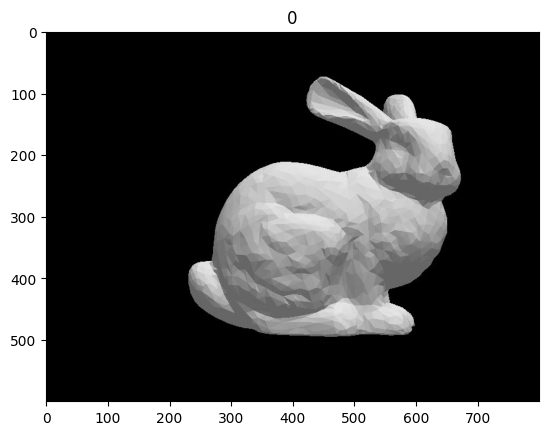

In [76]:
img = load_image(0)
show_image('0', img)

# This function thresholds the image and creates a mask

In [77]:
def make_mask(img, threshold=50, maxVal=255):

    # Convert to grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Apply the threshold
    ret,maskImg = cv.threshold(gray, threshold, maxVal, cv.THRESH_BINARY)

    return maskImg

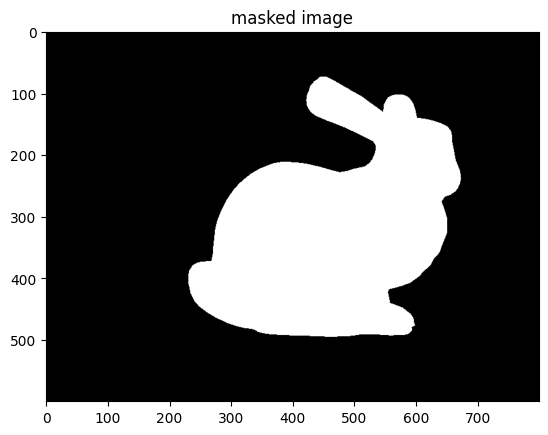

In [78]:
maskImg = make_mask(img)
show_image('masked image', maskImg)

# Use contour detection (boundary tracing) to get the perimeter

In [79]:
def get_boundary(img, showContours=True):
    # https://learnopencv.com/contour-detection-using-opencv-python-c/
    # https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0

    # detect the contours on the binary image using cv2.CHAIN_APPROX_NONE
    contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_NONE)

    contours = contours[0] # we only expect 1 contour in this example...
    x = contours[:,0,0]
    y = contours[:,0,1]

    if showContours == True:
        # draw contours on the original image
        #image_copy = img.copy()
        #cv.drawContours(image=image_copy, contours=contours, contourIdx=-1, color=(0, 255, 0), thickness=2, lineType=cv.LINE_AA)
        #show_image('contours', image_copy)
        show_image('contours', img)
        plt.plot(x, y, 'r.')


    # center the x axis about 0
    #x -= int(np.max(x) / 2.0)
    x -= 400    # This needs to be the center of rotation...
    
    # Invert the y axis
    #y = max(y) - y
    y = 640 - y

    return np.matrix((x, y)).T  # return x/y pairs

[[ 44 566]
 [ 43 565]
 [ 42 564]
 ...
 [ 47 566]
 [ 46 566]
 [ 45 566]]


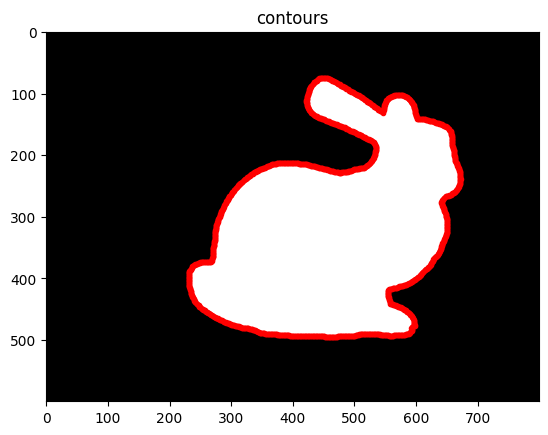

In [80]:
contours = get_boundary(maskImg)

print(contours)

# Rotate 3D

In [81]:
def rotate_3d(coords,angle=0,axis=[0,1,0]):

    theta = angle * np.pi / 180.

    Rx = np.matrix([[1,                 0,                  0],
                    [0,                 np.cos(theta),      -np.sin(theta)],
                    [0,                 np.sin(theta),      np.cos(theta)]
                  ])

    Ry = np.matrix([[np.cos(theta),     0,                  np.sin(theta)],
                    [0,                 1,                  0],
                    [-np.sin(theta),    0,                  np.cos(theta)]
                  ])

    Rz = np.matrix([[np.cos(theta),     -np.sin(theta),     0],
                    [np.sin(theta),     np.cos(theta),      0],
                    [0,                 0,                  1]
                  ])

    # TODO: Support rotation along other axes...
    rotationMatrix = Ry


    if type(coords) == type([]):
      
      coords_rotated = []

      if len(coords) > 0:
        for c in coords:
          if np.shape(c)[1] > 0:
            cr = rotationMatrix * c.T
            coords_rotated.append(cr.T)

    else:
      coords_rotated = rotationMatrix * coords.T
      coords_rotated = coords_rotated.T

    return coords_rotated

In [82]:
def contour_to_3d(contour2d):

    # Get the size of the contours (number of points)
    numPts,_ = np.shape(contour2d)

    # Add a zero vector to the contour matrix
    zVect = np.matrix(np.zeros((numPts, 1)))
    #contours_3d = np.hstack((contour2d[:,0], zVect, contour2d[:,1]))
    contours_3d = np.hstack((contour2d[:,0], contour2d[:,1], zVect))

    return contours_3d

Text(0, 0.5, 'z')

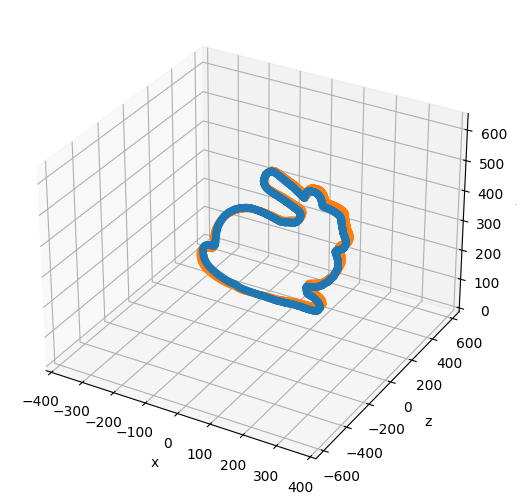

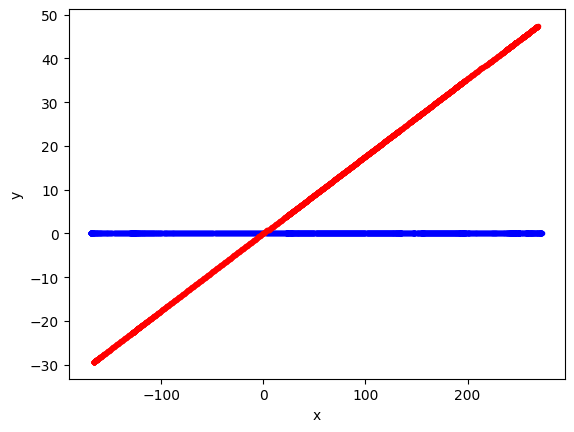

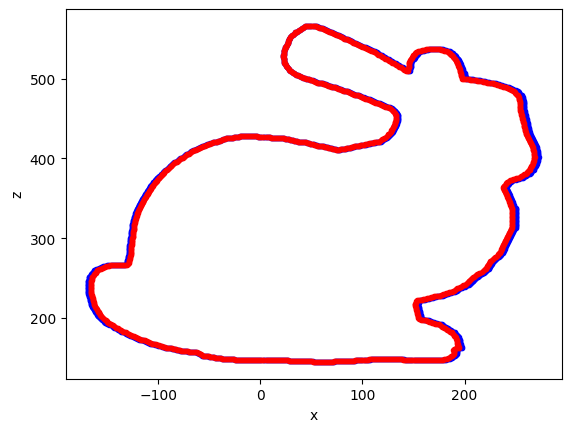

In [83]:
contours_3d = contour_to_3d(contours)

# Rotate the contours matrix by some amount
cont3drot = rotate_3d(contours_3d, -10.0)

# Plot the two sets of coordinates
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.scatter(contours_3d[:,0], contours_3d[:,2], contours_3d[:,1], 'b.')
ax.scatter(cont3drot[:,0], cont3drot[:,2], cont3drot[:,1], 'r.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)


fig2 = plt.figure()
plt.plot(contours_3d[:,0], contours_3d[:,2], 'b.')
plt.plot(cont3drot[:,0], cont3drot[:,2], 'r.')
plt.xlabel('x')
plt.ylabel('y')


fig3 = plt.figure()
plt.plot(contours_3d[:,0], contours_3d[:,1], 'b.')
plt.plot(cont3drot[:,0], cont3drot[:,1], 'r.')
plt.xlabel('x')
plt.ylabel('z')

# Test rotation alignment

Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 000deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 005deg.jpg...


(-193.14805762895233, 294.1092102079989, 123.9, 588.1)

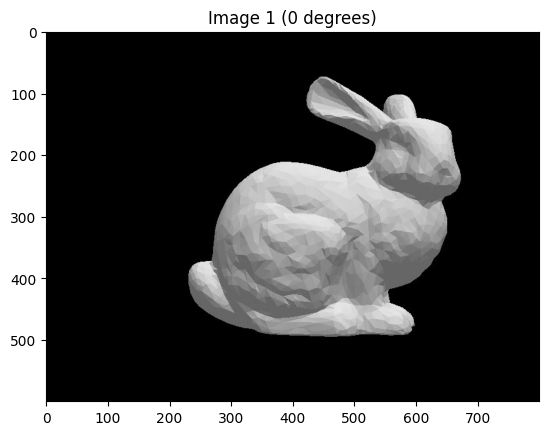

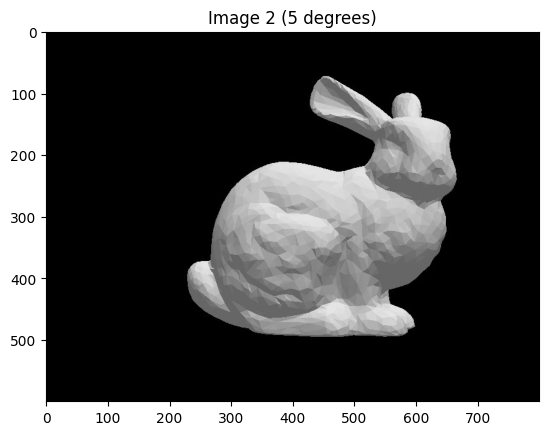

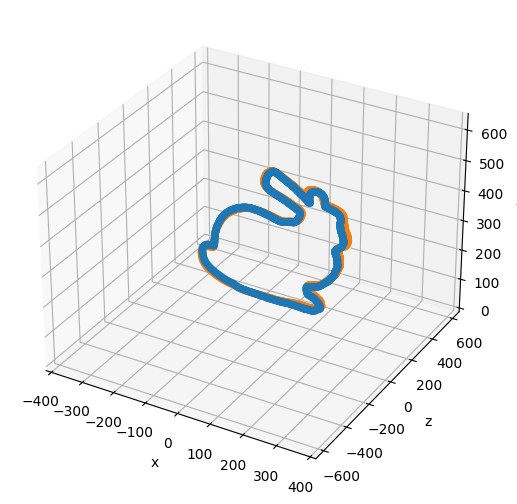

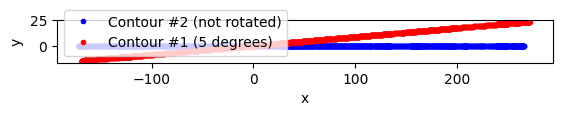

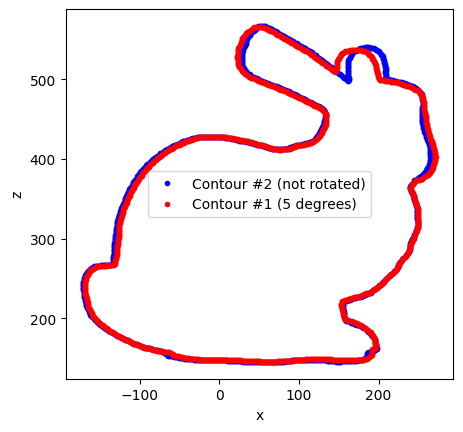

In [84]:
rotateAmount = 5

# Load the first contour
img1 = load_image(0)
maskImg1 = make_mask(img1)
contours1 = get_boundary(maskImg1, showContours=False)
contours1_3d = contour_to_3d(contours1)
show_image(f'Image 1 (0 degrees)', img1)

# Load the second contour
img2 = load_image(rotateAmount)
maskImg2 = make_mask(img2)
contours2 = get_boundary(maskImg2, showContours=False)
contours2_3d = contour_to_3d(contours2)
show_image(f'Image 2 ({rotateAmount} degrees)', img2)

# Rotate the first contour by the amount expected in the second contour
cont1_rotated = rotate_3d(contours1_3d, -rotateAmount)


# Plot the two contours to check alignment
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.scatter(contours2_3d[:,0], contours2_3d[:,2], contours2_3d[:,1], 'b.')
ax.scatter(cont1_rotated[:,0], cont1_rotated[:,2], cont1_rotated[:,1], 'r.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)


fig2 = plt.figure()
plt.plot(contours2_3d[:,0], contours2_3d[:,2], 'b.')
plt.plot(cont1_rotated[:,0], cont1_rotated[:,2], 'r.')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(('Contour #2 (not rotated)', f'Contour #1 ({rotateAmount} degrees)'))
plt.axis('image')

fig3 = plt.figure()
plt.plot(contours2_3d[:,0], contours2_3d[:,1], 'b.')
plt.plot(cont1_rotated[:,0], cont1_rotated[:,1], 'r.')
plt.xlabel('x')
plt.ylabel('z')
plt.legend(('Contour #2 (not rotated)', f'Contour #1 ({rotateAmount} degrees)'))
plt.axis('image')

# Slice through [DEPRECATED]

In [85]:
'''
def slice_through(currentContour, contourList):

    newList = []

    # Use the current contour as a polygon slice to intercept any of the other layers in the list (reject all points outside of the current contour)

    for c in contourList:
        # If any points within c fall outside of the current contour, remove them
        
        newPoints = []

        for pt in c:
            # determine if a point is inside, or outside, of the polygon formed by the contour vector
            x = pt[0, 0]
            y = pt[0, 1]
            z = pt[0, 2]
            pt = (x, z)

            result = cv.pointPolygonTest(currentContour, pt, measureDist=False)

            if result > 0:
                newPoints.append((x, y, z))
            #else:
            #    print(f'Removed ({x},{y},{z}) - {result}')

        fixedContour = np.matrix(newPoints)
        newList.append(fixedContour)

    return newList
'''

"\ndef slice_through(currentContour, contourList):\n\n    newList = []\n\n    # Use the current contour as a polygon slice to intercept any of the other layers in the list (reject all points outside of the current contour)\n\n    for c in contourList:\n        # If any points within c fall outside of the current contour, remove them\n        \n        newPoints = []\n\n        for pt in c:\n            # determine if a point is inside, or outside, of the polygon formed by the contour vector\n            x = pt[0, 0]\n            y = pt[0, 1]\n            z = pt[0, 2]\n            pt = (x, z)\n\n            result = cv.pointPolygonTest(currentContour, pt, measureDist=False)\n\n            if result > 0:\n                newPoints.append((x, y, z))\n            #else:\n            #    print(f'Removed ({x},{y},{z}) - {result}')\n\n        fixedContour = np.matrix(newPoints)\n        newList.append(fixedContour)\n\n    return newList\n"

# Try it out for all bunny pics [DEPRECATED]

In [86]:
'''
contourList = []

angleStep = 5
for angle in range(0, 360, angleStep):
    #print(f'Processing {angle} degrees...')

    img = load_image(angle)
    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)
    contours3d = contour_to_3d(contours)
    
    contourList = rotate_3d(contourList, -angleStep)

    contourList = slice_through(contours, contourList)
    contourList.append(contours3d)

endAngle2 = 20
for angle in range(0, endAngle2, angleStep):
    #print(f'Processing {angle} degrees...')

    img = load_image(angle)
    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)
    contours3d = contour_to_3d(contours)
    
    contourList = rotate_3d(contourList, -angleStep)

    contourList = slice_through(contours, contourList)



# Save the contour list to a file
pickle.dump(contourList, open('bunny_reconstructed.pickle','wb'))


# Plot the two sets of coordinates
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

for c in contourList:
    try:
        ax.scatter(c[:,0], c[:,1], c[:,2], 'r.')
    except:
        print(np.shape(c))

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)


# Save the figure to disk
#pickle.dump(fig, open('bunny_reconstructed.pickle','wb'))

# fig = pickle.load(open('bunny_reconstructed.pickle', 'rb'))
# fig.show()
'''

"\ncontourList = []\n\nangleStep = 5\nfor angle in range(0, 360, angleStep):\n    #print(f'Processing {angle} degrees...')\n\n    img = load_image(angle)\n    maskImg = make_mask(img)\n    contours = get_boundary(maskImg, showContours=False)\n    contours3d = contour_to_3d(contours)\n    \n    contourList = rotate_3d(contourList, -angleStep)\n\n    contourList = slice_through(contours, contourList)\n    contourList.append(contours3d)\n\nendAngle2 = 20\nfor angle in range(0, endAngle2, angleStep):\n    #print(f'Processing {angle} degrees...')\n\n    img = load_image(angle)\n    maskImg = make_mask(img)\n    contours = get_boundary(maskImg, showContours=False)\n    contours3d = contour_to_3d(contours)\n    \n    contourList = rotate_3d(contourList, -angleStep)\n\n    contourList = slice_through(contours, contourList)\n\n\n\n# Save the contour list to a file\npickle.dump(contourList, open('bunny_reconstructed.pickle','wb'))\n\n\n# Plot the two sets of coordinates\nfig = plt.figure()\nax =

In [87]:
'''
fig2 = plt.figure()
for c in contourList:
    for pt in c:
        x = pt[:,0]
        y = pt[:,2]
        z = pt[:,1]
        
        #if z <= 0:
        plt.plot(x, y, 'b.')
plt.xlabel('x')
plt.ylabel('y')
'''

"\nfig2 = plt.figure()\nfor c in contourList:\n    for pt in c:\n        x = pt[:,0]\n        y = pt[:,2]\n        z = pt[:,1]\n        \n        #if z <= 0:\n        plt.plot(x, y, 'b.')\nplt.xlabel('x')\nplt.ylabel('y')\n"

# Create a 3D version of the contour through multiple depth planes

In [88]:
def contour_to_3d_with_depth(contour2d, zMin=-640, zMax=640, zStep=1):

    # Get the size of the contours (number of points)
    numPts,_ = np.shape(contour2d)

    # Add a zero vector to the contour matrix
    zVect = np.matrix(np.zeros((numPts, 1)))
    
    # Create the 3d vector
    contours_3d = np.hstack((contour2d[:,0], contour2d[:,1], zVect))

    # Define the z coordinates
    z = np.matrix(np.arange(zMin, zMax+zStep, zStep)).T
    
    # Figure out how many elements we have in the z direction
    Nz = len(z)

    # Figure out how many elements we have in the contour
    Nxy = np.shape(contour2d)[0]

    # Replicate this stack
    contours_3d_deep = np.tile(contours_3d, (Nz, 1))

    # Add the z coordinates
    i = 0
    for iz in range(0, Nz):
        for ixy in range(0, Nxy):
            contours_3d_deep[i,2] = z[iz]
            i += 1

    return contours_3d_deep

Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 000deg.jpg...


(0.0, 640.0)

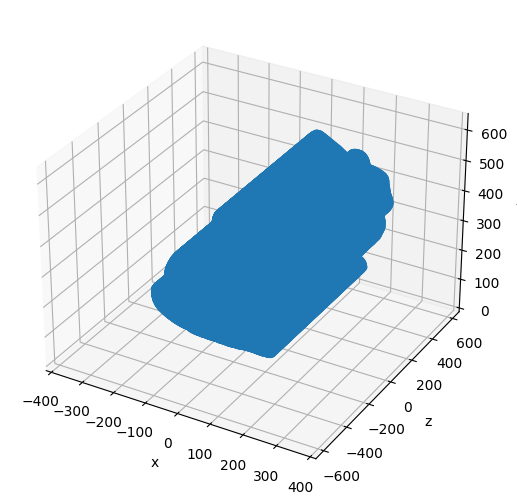

In [89]:
#print(contour_to_3d_with_depth(np.matrix([[0,0],[0,1],[0,2]]), -2, 2, 1))

# Load a test contour
img = load_image(0)
maskImg = make_mask(img1)
contours = get_boundary(maskImg, showContours=False)
contours3d_deep = contour_to_3d_with_depth(contours, zMin=-400, zMax=400, zStep=10)


# Plot the two contours to check alignment
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.scatter(contours3d_deep[:,0], contours3d_deep[:,2], contours3d_deep[:,1], 'b.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)

# Michelangelo

In [90]:
def michelangelo(contour, block):
    '''
    Carve out the parts that aren't David. 
    
    Each rotated view carves out a section of the "block". In this way, we remove
    the parts that aren't associated with the object.

    NOTE: this carving operation is done from the camera's perspective (from the 
          camera viewing angle). To do this in a less constrained environment, the
          camera angle (relative to the object) needs to be determined.
    '''

    newBlock = []

    for pt in block:
        # determine if a point is inside, or outside, of the polygon formed by the contour vector
        x = pt[0, 0]
        y = pt[0, 1]
        z = pt[0, 2]
        #pt = (x, z)
        pt = (x, y)

        # https://docs.opencv.org/3.4.5/d3/dc0/group__imgproc__shape.html#ga1a539e8db2135af2566103705d7a5722
        result = cv.pointPolygonTest(contour, pt, measureDist=False)

        if result >= 0:
            newBlock.append((x, y, z))


    newBlock = np.matrix(newBlock)
    
    return newBlock

# Carve Out the Block

In [91]:
def carve_block(angle, angleStep, block):
    
    img = load_image(angle)
    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)
    block = michelangelo(contours, block)
    block = rotate_3d(block, -angleStep)    # this rotation is along the correct world axis (axis the rotational stage is operating on)

    return block

In [92]:
#--------------------------------------------------
#  Initialize the block
#--------------------------------------------------
numPointsInEachAxis = 200

'''
x values: [[-157.5879397]], [[241.20603015]]
y values: [[-151.15577889]], [[112.56281407]]
z values: [[157.5879397]], [[562.81407035]]
'''

'''
xMin = -175
xMax = 250
yMin = -175
yMax = 250
zMin = 150
zMax = 575
x = np.linspace(xMin, xMax, numPointsInEachAxis)
y = np.linspace(yMin, yMax, numPointsInEachAxis)
z = np.linspace(zMin, zMax, numPointsInEachAxis)
xv, yv, zv = np.meshgrid(x, y, z)

xv = np.matrix(xv.flatten()).T
yv = np.matrix(yv.flatten()).T
zv = np.matrix(zv.flatten()).T

block = np.hstack((xv, yv, zv))


#--------------------------------------------------
#  Carve out bits of the block for each angle
#--------------------------------------------------

angleStep = 5
for angle in range(0, 360, angleStep):
    block = carve_block(angle, angleStep, block)


#--------------------------------------------------
#  Write the data to a file
#--------------------------------------------------

# Write to an ASC (point cloud) file
file = open('bunny.asc', 'w')
for pt in block:
    pt.tofile(file, sep=' ', format='%.6f')
    file.write('\n')
file.close()


#--------------------------------------------------
#  Plot the results
#--------------------------------------------------

# Get the individual x/y/z values
x = block[:,0]
y = block[:,1]
z = block[:,2]

print(f'x values: {min(x)}, {max(x)}')
print(f'y values: {min(y)}, {max(y)}')
print(f'z values: {min(z)}, {max(z)}')

# Plot the two sets of coordinates
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

ax.scatter(x, y, z, 'r.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)
'''



"\nxMin = -175\nxMax = 250\nyMin = -175\nyMax = 250\nzMin = 150\nzMax = 575\nx = np.linspace(xMin, xMax, numPointsInEachAxis)\ny = np.linspace(yMin, yMax, numPointsInEachAxis)\nz = np.linspace(zMin, zMax, numPointsInEachAxis)\nxv, yv, zv = np.meshgrid(x, y, z)\n\nxv = np.matrix(xv.flatten()).T\nyv = np.matrix(yv.flatten()).T\nzv = np.matrix(zv.flatten()).T\n\nblock = np.hstack((xv, yv, zv))\n\n\n#--------------------------------------------------\n#  Carve out bits of the block for each angle\n#--------------------------------------------------\n\nangleStep = 5\nfor angle in range(0, 360, angleStep):\n    block = carve_block(angle, angleStep, block)\n\n\n#--------------------------------------------------\n#  Write the data to a file\n#--------------------------------------------------\n\n# Write to an ASC (point cloud) file\nfile = open('bunny.asc', 'w')\nfor pt in block:\n    pt.tofile(file, sep=' ', format='%.6f')\n    file.write('\n')\nfile.close()\n\n\n#---------------------------

# Initializing the block with deep bunnies

In [106]:
#--------------------------------------------------
#  Initialize the block
#--------------------------------------------------
zMin = -400    # check these values
zMax = 400     # check these values
zStep = 5
block = None

angleStep = 5
angleMax = 360

#--------------------------------------------------
#  Carve out bits of the block for each angle
#--------------------------------------------------
rotatedAngle = 0
for angle in range(0, angleMax, angleStep):
    img = load_image(angle)
    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)

    if block is not None:
        block = michelangelo(contours, block)
        
    b = contour_to_3d_with_depth(contours, zMin, zMax, zStep)
    if block is None:
        block = b.copy()
    else:
        block = np.vstack((block, b))
    
    block = rotate_3d(block, -angleStep)    # this rotation is along the correct world axis (axis the rotational stage is operating on)
    rotatedAngle -= angleStep


if abs(rotatedAngle) == 360:
    rotatedAngle = 0

# Take a second pass to carve out unneeded points
for angle in range(0, angleMax, angleStep):
    img = load_image(angle)
    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)

    print(f'Cutting at angle {rotatedAngle}...')

    block = michelangelo(contours, block)
    block = rotate_3d(block, -angleStep)    # this rotation is along the correct world axis (axis the rotational stage is operating on)
    rotatedAngle -= angleStep


#--------------------------------------------------
#  Write the data to a file
#--------------------------------------------------
# Write to an ASC (point cloud) file
file = open('bunny.asc', 'w')
for pt in block:
    pt.tofile(file, sep=' ', format='%.6f')
    file.write('\n')
file.close()


#--------------------------------------------------
#  Plot the results
#--------------------------------------------------
'''
# Get the individual x/y/z values
x = block[:,0]
y = block[:,1]
z = block[:,2]

print(f'x values: {min(x)}, {max(x)}')
print(f'y values: {min(y)}, {max(y)}')
print(f'z values: {min(z)}, {max(z)}')

# Plot the two sets of coordinates
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

ax.scatter(x, z, y, 'r.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)
'''


#'''
block_pv = pv.wrap(block)
dargs = dict(show_edges=True)
p = pv.Plotter()
p.add_mesh(block_pv, color='r', point_size=3.0, render_points_as_spheres=True)
p.show()

print(p.scale)
#'''

Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 000deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 005deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 010deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 015deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 020deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 025deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 030deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 035deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 040deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 045deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 050deg.jpg...
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 055deg

Widget(value="<iframe src='http://localhost:53344/index.html?ui=P_0x1ee8364c0d0_21&reconnect=auto' style='widt…

[1.0, 1.0, 1.0]


In [123]:
# Get the individual x/y/z values
x = block[:,0]
y = block[:,1]
z = block[:,2]

print(f'x values: {min(x)}, {max(x)}')
print(f'y values: {min(y)}, {max(y)}')
print(f'z values: {min(z)}, {max(z)}')

x values: [[-159.63952277]], [[247.]]
y values: [[157.]], [[563.]]
z values: [[-125.17059054]], [[156.58443273]]


In [122]:
cloud = pv.PolyData(block_pv)
#cloud.plot()

surf = cloud.delaunay_3d(alpha=7.2, progress_bar=True)   # >= 1.414 * the z-axis gap size  (I think...)
#surf.plot(show_edges=True, cpos="xy")

#print(surf.volume)

#surf = cloud.reconstruct_surface(nbr_sz=20, sample_spacing=2)
#surf.plot(show_edges=True, cpos="xy")


# Use pymeshfix to repair the mesh:  https://stackoverflow.com/questions/68777480/struggling-to-create-watertight-meshes-out-of-point-cloud-data-using-open3d-in-p
#mf = pymeshfix.MeshFix(surf)
#mf.repair()
#repaired = mf.mesh
#repaired.plot(show_edges=True, cpos="xy")


surf = surf.clean()
surf = surf.extract_surface()
surf = surf.triangulate()
surf.plot(show_edges=False)

Computing 3D Triangulation: 100%|██████████[00:26<00:00]


Widget(value="<iframe src='http://localhost:53344/index.html?ui=P_0x1eeb02febd0_32&reconnect=auto' style='widt…

# Use PyVista to process 3D objects

In [95]:
def get_point_mesh(contour, gridSpacing=5):
    ''' Accepts a 2D contour and returns a grid of 3D points (pyvista object) '''
    
    xMin = min(contour[:,0])
    xMax = max(contour[:,0])
    x = np.arange(xMin, xMax+gridSpacing, gridSpacing)
    
    yMin = min(contour[:,1])
    yMax = max(contour[:,1])
    y = np.arange(yMin, yMax+gridSpacing, gridSpacing)

    xv, yv = np.meshgrid(x, y)

    xv = np.matrix(xv.flatten()).T
    yv = np.matrix(yv.flatten()).T
    zv = np.matrix(np.zeros(np.shape(xv)))

    grid = np.hstack((xv, yv, zv))

    gridFinal = []

    for pt in grid:
        x = pt[0, 0]
        y = pt[0, 1]
        z = pt[0, 2]
        pt2 = (x, y)

        result = cv.pointPolygonTest(contour, pt2, measureDist=False)

        if result > 0:
            gridFinal.append((x,y,z))

    for pt in contour:
        x = pt[0, 0]
        y = pt[0, 1]
        z = 0
        gridFinal.append((x,y,z))

    gridFinal = np.matrix(gridFinal)
    pvPoints = pv.PolyData(gridFinal)

    return pvPoints

In [96]:
def get_extruded_bunny(angle, extrudeAmount=800, plot=False):

    # Load a contour
    img = load_image(angle)
    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)
    #contours3d = contour_to_3d(contours)

    # Create a points object from the contour dataset
    #polygon = pv.wrap(contours3d)

    points = get_point_mesh(contours)
    #points.plot()

    cloud = pv.PolyData(points)
    #cloud.plot()

    surf = cloud.delaunay_2d(tol=1e-5, alpha=3.6)
    #surf.plot(show_edges=True, cpos="xy")

    surf = surf.clean()


    '''
    plane = pv.Plane(
        center=(surf.center[0], surf.center[1], -extrudeAmount),
        direction=(0, 0, -1),
        i_size=1000,
        j_size=1000,
    )

    # https://docs.pyvista.org/version/stable/api/core/_autosummary/pyvista.PolyDataFilters.extrude_trim.html
    extruded = surf.extrude_trim((0, 0, -1.0), plane, extrusion='all_edges')
    '''

    extruded = surf.extrude((0, 0, -extrudeAmount), capping=True)


    #extruded = surf
    #extrudeStep = extrudeAmount / 10
    #for i in np.arange(0, extrudeAmount, extrudeStep):
    #    extruded = extruded.extrude((0, 0, -extrudeStep), capping=True)


    extruded.translate((0,0,(extrudeAmount/2)), inplace=True)
    extruded.rotate_y(angle, (0,0,0), inplace=True)

    extruded = extruded.clean()

    extruded = extruded.extract_surface()

    extruded = extruded.triangulate()

    #extruded = extruded.extract_surface()
    
    #extruded = pv.voxelize(extruded, density=20)


    if plot == True:
        extruded.plot(show_edges=True, line_width=5, cpos="xy")

    return extruded

In [97]:
extruded1 = get_extruded_bunny(0)
#print('Is all triangles?', extruded1.is_all_triangles)
print('Volume:', extruded1.volume)
#extruded1.plot(show_edges=True, line_width=5, cpos="xy")

rotateAmount = 45
extruded2 = get_extruded_bunny(rotateAmount)
#print('Is all triangles?', extruded2.is_all_triangles)
print('Volume:', extruded2.volume)
#extruded2.plot(show_edges=True, line_width=5, cpos="xy")


# Intersect the two objects
#intersection = extruded1.boolean_intersection(extruded2)
#intersection.plot(show_edges=True, line_width=5, cpos="xy")

#centers = extruded1.cell_centers()

dargs = dict(show_edges=True)

p = pv.Plotter()
p.add_mesh(extruded1, color="Crimson", **dargs)
p.add_mesh(extruded2, color="mintcream", opacity=0.35, **dargs)
#p.camera_position = cpos
#p.add_mesh(centers, color='r', point_size=8.0, render_points_as_spheres=True)
p.show()

Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 000deg.jpg...
Volume: 5741812.637452814
Loading "c:\Dropbox (Meta)\Jupyter\Crystal_Rotation\bunny_pics\Bunny_ 045deg.jpg...
Volume: 1434326.7301096069


Widget(value="<iframe src='http://localhost:53344/index.html?ui=P_0x1ee9465db50_15&reconnect=auto' style='widt…

In [98]:
'''
n = 101
xx = np.linspace(-500, 500, n)
yy = np.linspace(0, 640, n)
zz = np.linspace(-500, 500, n)
block = pv.RectilinearGrid(xx, yy, zz)

block.compute_implicit_distance(extruded1, inplace=True)
inner = block.threshold(0.0, scalars='implicit_distance', invert=True)

#block = block.clip_surface(extruded1, invert=False)

dargs = dict(show_edges=True)

p = pv.Plotter()
p.add_mesh(inner, color="lightblue", **dargs)
p.show()
'''


'''
selection = extruded1.select_enclosed_points(extruded2)
threshold = 0.5
outside = selection.threshold(threshold, invert=True)
inside = selection.threshold(threshold)

dargs = dict(show_edges=True)

p = pv.Plotter()
p.add_mesh(inside, color="lightblue", **dargs)
p.add_mesh(outside, color="blue", **dargs)
p.show()
'''


'''
clipped = extruded1.compute_implicit_distance(extruded2)
inner = clipped.threshold(0.0, scalars="implicit_distance", invert=True)

p = pv.Plotter()
p.add_mesh(inner, color="lightblue", **dargs)
p.show()
'''

'\nclipped = extruded1.compute_implicit_distance(extruded2)\ninner = clipped.threshold(0.0, scalars="implicit_distance", invert=True)\n\np = pv.Plotter()\np.add_mesh(inner, color="lightblue", **dargs)\np.show()\n'

# Trying pymeshlab...

In [99]:
#meshSet = pymeshlab.MeshSet()



# Trying Trimesh

In [100]:
#  https://trimesh.org/trimesh.boolean.html#trimesh.boolean.intersection